In [63]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score


In [64]:
data=load_breast_cancer()
X = data.data
Y = data.target

In [65]:
pca = PCA(n_components=2)
X = pca.fit_transform(X)

In [66]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42)

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
model = SVC(kernel="linear", C=1)
model.fit(X_train, Y_train)

SVC(C=1, kernel='linear')

In [69]:
Y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9649122807017544


In [70]:
def plot_svm(model, X, Y):

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm")

    ax = plt.gca()

  
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy)
    Z = Z.reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0], colors="black")
    ax.contour(XX, YY, Z, levels=[-1, 1], colors="black", linestyles="dashed")

    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black"
    )

    plt.title("Linear SVM Decision Boundary")
    plt.show()
    
    
    
    

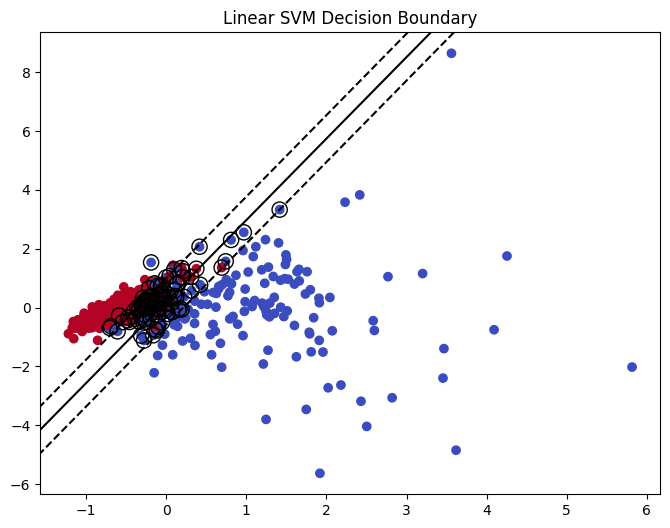

In [71]:
plot_svm(model, X_train,Y_train)